# Fetal Head Clinical AI -- Phase 4a v10: Iterative Prune→Fine-Tune Cycles

**Key innovation:** Sequential burst pruning with adaptive batch sizing + multi-cycle prune→KD recovery for maximum structural compression while maintaining clinical-grade accuracy.

## 0. Setup

In [ ]:
!pip install kaggle albumentations==1.4.0 thop onnx onnxruntime-gpu onnxscript --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
import os, json, shutil, random, time, copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
PHASE0_CKPT = PROJECT_DIR / 'checkpoints' / 'phase0' / 'best_model.pth'
CKPT_DIR    = PROJECT_DIR / 'checkpoints' / 'phase4a'
RESULTS_DIR = PROJECT_DIR / 'results' / 'phase4a'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_H, INPUT_W = 256, 384

# -- Stage 1: AGGRESSIVE pruning across 5 blocks --
DICE_DROP_MAX    = 0.04
MAE_INCREASE_MAX = 1.50
HARD_FLOORS = {
    'enc3': 64,         # 128 -> 64 (50%)
    'enc4': 128,        # 256 -> 128 (50%)
    'bottleneck': 256,  # 512 -> 256 (50%) -- NEW in v8
    'dec4': 128,        # 256 -> 128 (50%) -- NEW in v8
    'dec3': 64,         # 128 -> 64 (50%)  -- NEW in v8
}
ILR_W = {'rms': 0.6, 'bn_gamma': 0.4, 'hrank': 0.2}

# -- Stage 2: Fine-tuning with KD --
FT_EPOCHS     = 30
FT_LR         = 1e-4
FT_BATCH_SIZE = 8
KD_ALPHA      = 0.5
KD_TEMP       = 4.0

BASELINE_DICE = 0.9736
BASELINE_MAE  = 1.75

assert PHASE0_CKPT.exists(), 'Phase 0 checkpoint missing'
print('Config ready.')
print(f'Stage 1: Dice drop <={DICE_DROP_MAX*100:.0f}pp | MAE increase <={MAE_INCREASE_MAX}mm')
print(f'Hard floors: {HARD_FLOORS}')
print(f'Stage 2: {FT_EPOCHS} epochs FT with KD (alpha={KD_ALPHA}, T={KD_TEMP})')

Mounted at /content/drive
Config ready.
Stage 1: Dice drop <=4pp | MAE increase <=1.5mm
Hard floors: {'enc3': 64, 'enc4': 128, 'bottleneck': 256, 'dec4': 128, 'dec3': 64}
Stage 2: 30 epochs FT with KD (alpha=0.5, T=4.0)


## 1. Model Architecture + Parameter Breakdown

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        )
        self.skip = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x): return self.block(x) + self.skip(x)

class ResidualUNetDS(nn.Module):
    def __init__(self, in_ch=1, base_ch=32):
        super().__init__()
        b = base_ch
        self.enc1=ResidualBlock(in_ch,b); self.enc2=ResidualBlock(b,b*2)
        self.enc3=ResidualBlock(b*2,b*4); self.enc4=ResidualBlock(b*4,b*8)
        self.pool=nn.MaxPool2d(2); self.bottleneck=ResidualBlock(b*8,b*16)
        self.up4=nn.ConvTranspose2d(b*16,b*8,2,stride=2); self.dec4=ResidualBlock(b*16,b*8)
        self.up3=nn.ConvTranspose2d(b*8,b*4,2,stride=2);  self.dec3=ResidualBlock(b*8,b*4)
        self.up2=nn.ConvTranspose2d(b*4,b*2,2,stride=2);  self.dec2=ResidualBlock(b*4,b*2)
        self.up1=nn.ConvTranspose2d(b*2,b,2,stride=2);    self.dec1=ResidualBlock(b*2,b)
        self.final=nn.Conv2d(b,1,1); self.aux_d3=nn.Conv2d(b*4,1,1); self.aux_d2=nn.Conv2d(b*2,1,1)
    def forward(self, x):
        e1=self.enc1(x);e2=self.enc2(self.pool(e1));e3=self.enc3(self.pool(e2));e4=self.enc4(self.pool(e3))
        bn=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(bn),e4],1));d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1));d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        if self.training:
            return self.final(d1), \
                torch.sigmoid(F.interpolate(self.aux_d3(d3),size=x.shape[2:],mode='bilinear',align_corners=False)), \
                torch.sigmoid(F.interpolate(self.aux_d2(d2),size=x.shape[2:],mode='bilinear',align_corners=False))
        return self.final(d1)

phase0_model = ResidualUNetDS(in_ch=1, base_ch=32)
phase0_model.load_state_dict(torch.load(str(PHASE0_CKPT), map_location='cpu')['model_state_dict'])
phase0_model = phase0_model.to(DEVICE).eval()
total_params = sum(p.numel() for p in phase0_model.parameters())
print(f'Phase 0 loaded. Parameters: {total_params:,}')

Phase 0 loaded. Parameters: 8,110,789


In [ ]:
# Checklist step 4: Parameter breakdown per block
def param_breakdown(model):
    blocks = {
        'enc1': [model.enc1], 'enc2': [model.enc2],
        'enc3': [model.enc3], 'enc4': [model.enc4],
        'bottleneck': [model.bottleneck],
        'up4+dec4': [model.up4, model.dec4], 'up3+dec3': [model.up3, model.dec3],
        'up2+dec2': [model.up2, model.dec2], 'up1+dec1': [model.up1, model.dec1],
        'heads': [model.final, model.aux_d3, model.aux_d2],
    }
    total = sum(p.numel() for p in model.parameters())
    print(f'{"Block":<15} {"Params":>10} {"% of total":>10}  {"Channels":>8}  Prunable?')
    print('-' * 65)
    for name, modules in blocks.items():
        n = sum(p.numel() for m in modules for p in m.parameters())
        ch = ''
        if hasattr(modules[0], 'block'):
            ch = str(modules[0].block[-1].out_channels)
        print(f'{name:<15} {n:>10,} {n/total*100:>9.1f}%  {ch:>8}  '
              f'{"<-- YES" if name in ["enc3","enc4","bottleneck","up4+dec4","up3+dec3"] else ""}')
    print('-' * 65)
    print(f'{"TOTAL":<15} {total:>10,} {100.0:>9.1f}%')

param_breakdown(phase0_model)

Block               Params % of total  Channels  Prunable?
-----------------------------------------------------------------
enc1                 9,602       0.1%        32  
enc2                57,536       0.7%        64  
enc3               229,760       2.8%       128  <-- YES
enc4               918,272      11.3%       256  <-- YES
bottleneck       3,671,552      45.3%       512  <-- YES
up4+dec4         2,426,624      29.9%            <-- YES
up3+dec3           607,104       7.5%            <-- YES
up2+dec2           152,000       1.9%            
up1+dec1            38,112       0.5%            
heads                  227       0.0%            
-----------------------------------------------------------------
TOTAL            8,110,789     100.0%


## 2. Load HC18 Dataset + DataLoaders

In [ ]:
from google.colab import files as colab_files
uploaded = colab_files.upload()  # upload kaggle.json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

DATA_DIR = Path('/content/hc18')
DATA_DIR.mkdir(exist_ok=True)
!kaggle datasets download -d tarunsadarla/hc18-apr -p /content/hc18 --unzip --quiet

TRAIN_DIR = DATA_DIR / 'archive (4)' / 'training_set' / 'training_set'
PIXEL_CSV = DATA_DIR / 'archive (4)' / 'training_set_pixel_size_and_HC.csv'
df_meta = pd.read_csv(PIXEL_CSV)
df_meta.columns = [c.strip().lower().replace(' ','_').replace('(','').replace(')','') for c in df_meta.columns]
PIXEL_COL = [c for c in df_meta.columns if 'pixel' in c][0]
HC_COL    = [c for c in df_meta.columns if 'head' in c or ('hc' in c.lower() and 'circumference' in c.lower())][-1]
FILE_COL  = [c for c in df_meta.columns if 'file' in c][0]
stem_to_meta = {
    str(row[FILE_COL]).replace('_HC.png','').replace('_2HC.png','').replace('_3HC.png','').replace('_4HC.png','').replace('.png',''): {
        'pixel_spacing': float(row[PIXEL_COL]), 'hc_gt_mm': float(row[HC_COL])
    } for _, row in df_meta.iterrows()
}

# Load exact same test split from Phase 0
with open(str(PROJECT_DIR / 'results' / 'phase0' / 'data_split.json')) as f:
    split_record = json.load(f)

annotation_files = sorted(TRAIN_DIR.glob('*_Annotation.png'))
image_mask_pairs = [(TRAIN_DIR/ann.name.replace('_Annotation.png','.png'), ann)
                    for ann in annotation_files if (TRAIN_DIR/ann.name.replace('_Annotation.png','.png')).exists()]
stem_to_pair = {ip.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC',''): (ip,mp)
                for ip,mp in image_mask_pairs}

test_pairs  = [stem_to_pair[s] for s in split_record['test']  if s in stem_to_pair]
val_pairs   = [stem_to_pair[s] for s in split_record['val']   if s in stem_to_pair]
train_pairs = [stem_to_pair[s] for s in split_record['train'] if s in stem_to_pair]
calib_pairs = random.sample(val_pairs, min(40, len(val_pairs)))  # 40-sample calibration subset

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')
print(f'Calibration subset (from val): {len(calib_pairs)}')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/hc18-apr
License(s): apache-2.0
Train: 564 | Val: 121 | Test: 121
Calibration subset (from val): 40


In [ ]:
def load_static_pair(img_path, mask_path, h=INPUT_H, w=INPUT_W):
    """
    Load an HC18 image+annotation pair, matching Phase 0's exact preprocessing.

    FILL METHOD: Phase 0 uses cv2.floodFill from corner (0,0) and inverts.
    This is more robust than findContours+fillPoly on thin outline masks.

    NORMALIZATION: Phase 0 val_transform = A.Normalize(mean=0, std=1, max=255)
    i.e. simply divide by 255 — no mean subtraction, no std division.
    Phase 4a must match this exactly or Dice will be ~92% instead of ~97%.
    """
    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if img is None:  raise FileNotFoundError(f'Image not found: {img_path}')
    if mask is None: raise FileNotFoundError(f'Mask not found: {mask_path}')

    # Fill at original resolution (800x540) — same as Phase 0 HC18Dataset
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    flood_mask  = np.zeros((mask_bin.shape[0]+2, mask_bin.shape[1]+2), dtype=np.uint8)
    filled      = mask_bin.copy()
    cv2.floodFill(filled, flood_mask, (0, 0), 255)  # flood from top-left corner
    filled_inv  = cv2.bitwise_not(filled)
    solid_mask  = cv2.bitwise_or(mask_bin, filled_inv)
    solid_mask  = (solid_mask > 127).astype(np.uint8)

    img_r  = cv2.resize(img,        (w, h))
    mask_r = cv2.resize(solid_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    return img_r, (mask_r > 0).astype(np.uint8)


def img_to_tensor(img_gray):
    """
    Normalize exactly as Phase 0's val_transform:
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0) → divide by 255 only.
    Phase 0 did NOT subtract 0.2 or divide by 0.15.
    """
    t = torch.from_numpy(img_gray.astype(np.float32) / 255.0)  # [0, 1]
    return t.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]


def estimate_hc_mm(mask_bin, pixel_spacing_mm, input_w=INPUT_W, orig_w=800):
    lbl = label(mask_bin)
    if lbl.max() == 0: return None
    largest = max(regionprops(lbl), key=lambda r: r.area)
    a, b = largest.major_axis_length/2, largest.minor_axis_length/2
    if a < 1 or b < 1: return None
    h_v = ((a-b)/(a+b+1e-8))**2
    hc_px = np.pi*(a+b)*(1+(3*h_v)/(10+np.sqrt(4-3*h_v+1e-8)))
    return hc_px * pixel_spacing_mm * (orig_w / input_w)


# Verify fill matches Phase 0
img_s, mask_s = load_static_pair(*test_pairs[0])
assert mask_s.sum() > 5000, f'Fill failed: sum={mask_s.sum()}'
print(f'Fill OK — mask sum: {mask_s.sum()} (expect ~10,000-15,000)')
print(f'Image range: [{img_s.min():.0f}, {img_s.max():.0f}] (uint8 grayscale)')
t_test = img_to_tensor(img_s)
print(f'Tensor range: [{t_test.min():.4f}, {t_test.max():.4f}] (expect [0, 1])')


Fill OK — mask sum: 14481 (expect ~10,000-15,000)
Image range: [0, 243] (uint8 grayscale)
Tensor range: [0.0000, 0.9529] (expect [0, 1])


In [ ]:
# Augmentation pipelines (matching Phase 0 exactly)
train_transform = A.Compose([
    A.Resize(INPUT_H, INPUT_W),
    A.Rotate(limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.ElasticTransform(alpha=30, sigma=5, border_mode=cv2.BORDER_CONSTANT, p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0,
                       border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.3),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.Resize(INPUT_H, INPUT_W),
    A.Normalize(mean=0.0, std=1.0, max_pixel_value=255.0),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

class HC18Dataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        stem = img_path.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
        img  = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if img is None: raise FileNotFoundError(f'Image not found: {img_path}')
        _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        flood_mask = np.zeros((mask_bin.shape[0]+2, mask_bin.shape[1]+2), dtype=np.uint8)
        filled = mask_bin.copy()
        cv2.floodFill(filled, flood_mask, (0, 0), 255)
        filled_inv = cv2.bitwise_not(filled)
        solid_mask = cv2.bitwise_or(mask_bin, filled_inv)
        solid_mask = (solid_mask > 127).astype(np.uint8)
        if self.transform:
            augmented = self.transform(image=img, mask=solid_mask)
            img      = augmented['image']
            mask_out = augmented['mask'].unsqueeze(0).float()
        else:
            img      = torch.from_numpy(img).unsqueeze(0).float() / 255.0
            mask_out = torch.from_numpy(solid_mask).unsqueeze(0).float()
        return img, mask_out, stem

train_dataset = HC18Dataset(train_pairs, transform=train_transform)
val_dataset   = HC18Dataset(val_pairs,   transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=FT_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=FT_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_pairs)}')

Train: 564 | Val: 121 | Test: 121


## 3. Evaluation Utilities

In [ ]:
@torch.no_grad()
def evaluate_static(model, pairs, max_n=None, device=DEVICE):
    model.eval()
    dice_scores, mae_errors = [], []
    smooth = 1e-5
    eval_pairs = pairs[:max_n] if max_n else pairs
    for img_path, mask_path in eval_pairs:
        stem = img_path.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
        meta = stem_to_meta.get(stem, {})
        ps   = meta.get('pixel_spacing', 0.08)
        hcgt = meta.get('hc_gt_mm', 0.0)
        img, mask = load_static_pair(img_path, mask_path)
        img_t     = img_to_tensor(img).to(device)
        pred      = torch.sigmoid(model(img_t)).cpu().squeeze().numpy()
        pred_bin  = (pred > 0.5).astype(np.uint8)
        inter = (pred_bin * mask).sum()
        dice  = (2*inter + smooth) / (pred_bin.sum() + mask.sum() + smooth)
        dice_scores.append(float(dice))
        if ps > 0 and hcgt > 0:
            hc_pred = estimate_hc_mm(pred_bin, ps)
            if hc_pred: mae_errors.append(abs(hc_pred - hcgt))
    return {
        'mean_dice': float(np.mean(dice_scores)) if dice_scores else 0.0,
        'mean_mae':  float(np.mean(mae_errors))  if mae_errors  else 99.0,
        'n': len(dice_scores)
    }

@torch.no_grad()
def evaluate_per_sample(model, pairs, device=DEVICE):
    """Return per-sample Dice and MAE lists for statistical tests."""
    model.eval()
    dice_list, mae_list = [], []
    smooth = 1e-5
    for img_path, mask_path in pairs:
        stem = img_path.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
        meta = stem_to_meta.get(stem, {})
        ps   = meta.get('pixel_spacing', 0.08)
        hcgt = meta.get('hc_gt_mm', 0.0)
        img, mask = load_static_pair(img_path, mask_path)
        img_t = img_to_tensor(img).to(device)
        pred  = torch.sigmoid(model(img_t)).cpu().squeeze().numpy()
        pred_bin = (pred > 0.5).astype(np.uint8)
        inter = (pred_bin * mask).sum()
        dice  = (2*inter + smooth) / (pred_bin.sum() + mask.sum() + smooth)
        dice_list.append(float(dice))
        if ps > 0 and hcgt > 0:
            hc_pred = estimate_hc_mm(pred_bin, ps)
            mae_list.append(abs(hc_pred - hcgt) if hc_pred else None)
        else:
            mae_list.append(None)
    return dice_list, mae_list

BASELINE_DICE = 0.9736
BASELINE_MAE  = 1.75
print(f'Guard rail floor: Dice >= {(BASELINE_DICE-DICE_DROP_MAX)*100:.2f}% | MAE <= {BASELINE_MAE+MAE_INCREASE_MAX:.2f}mm')
phase0_verify = evaluate_static(phase0_model, test_pairs)
print(f'Phase 0 test: Dice={phase0_verify["mean_dice"]*100:.2f}% | MAE={phase0_verify["mean_mae"]:.2f}mm')

Guard rail floor: Dice >= 93.36% | MAE <= 3.25mm
Phase 0 test: Dice=97.75% | MAE=1.65mm


## 4. ILR Scoring

In [ ]:
def compute_ilr_scores(model, pairs, n_batches=8, device=DEVICE):
    """Compute ILR importance for ALL prunable blocks."""
    model.eval()
    blocks = {
        'enc3':       {'conv': model.enc3.block[-1]},
        'enc4':       {'conv': model.enc4.block[-1]},
        'bottleneck': {'conv': model.bottleneck.block[-1]},
        'dec4':       {'conv': model.dec4.block[-1]},
        'dec3':       {'conv': model.dec3.block[-1]},
    }
    act_accum  = {k: None for k in blocks}
    frob_accum = {k: None for k in blocks}
    act_count  = {k: 0    for k in blocks}
    hooks = []

    def make_hook(name):
        def h(m, inp, out):
            out_d = out.detach().float()
            rms  = out_d.pow(2).mean(dim=[0,2,3])
            frob = out_d.pow(2).sum(dim=[2,3]).sqrt().mean(dim=0)
            if act_accum[name] is None:
                act_accum[name]  = torch.zeros(rms.shape)
                frob_accum[name] = torch.zeros(frob.shape)
            act_accum[name]  += rms.cpu()
            frob_accum[name] += frob.cpu()
            act_count[name]  += 1
        return h

    for name, spec in blocks.items():
        hooks.append(spec['conv'].register_forward_hook(make_hook(name)))

    with torch.no_grad():
        for i, (img_path, _) in enumerate(pairs[:n_batches]):
            img = cv2.resize(cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE), (INPUT_W, INPUT_H))
            model(img_to_tensor(img).to(device))

    for h in hooks: h.remove()

    def normalize(x):
        lo, hi = x.min(), x.max()
        return (x-lo)/(hi-lo+1e-10) if (hi-lo) > 1e-10 else torch.ones_like(x)*0.5

    ilr = {}
    for name, spec in blocks.items():
        n    = max(1, act_count[name])
        rms  = normalize((act_accum[name] / n).sqrt())
        frb  = normalize(frob_accum[name] / n)
        w_l1 = spec['conv'].weight.data.abs().sum(dim=[1,2,3]).cpu()
        gam  = normalize(w_l1)
        ilr[name] = (ILR_W['rms']*rms + ILR_W['bn_gamma']*gam + ILR_W['hrank']*frb) / sum(ILR_W.values())

    for name, scores in ilr.items():
        si = torch.argsort(scores)
        print(f'{name:12s}: {scores.shape[0]:3d} ch | min={scores.min():.4f} mean={scores.mean():.4f} max={scores.max():.4f} | weakest: {si[:3].tolist()}')
    return ilr

print('ILR scores on calibration set:')
ilr_scores = compute_ilr_scores(phase0_model, calib_pairs)

ILR scores on calibration set:
enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4        : 256 ch | min=0.0910 mean=0.3518 max=0.7961 | weakest: [135, 1, 164]
bottleneck  : 512 ch | min=0.0303 mean=0.3699 max=0.9443 | weakest: [504, 285, 17]
dec4        : 256 ch | min=0.0272 mean=0.3078 max=0.8602 | weakest: [110, 221, 246]
dec3        : 128 ch | min=0.0421 mean=0.3754 max=0.9000 | weakest: [5, 62, 37]


## 5. Hybrid Crossover Merger

In [ ]:
class HybridCrossoverMerger:
    """v8: Hybrid Crossover merging for ALL ResidualUNetDS blocks.

    Prunable blocks and their downstream effects:
      enc3       -> enc4.block[0/2], enc4.skip, dec3.block[0/2], dec3.skip
      enc4       -> bottleneck.block[0/2], bottleneck.skip, dec4.block[0/2], dec4.skip
      bottleneck -> up4 (in_channels shrinks), dec4 cat changes (up4 output shrinks)
      dec4       -> up3 is NOT affected (up3.in_ch = dec4.out_ch, but we prune dec4.out_ch)
                    so up3.in_channels shrinks, dec3 cat changes
                    also aux head if connected
      dec3       -> up2 is NOT affected similarly, aux_d3 in_channels changes
    """

    # Maps: block -> next sequential block (encoder path or decoder path)
    _NEXT_BLOCK = {
        'enc3': 'enc4',
        'enc4': 'bottleneck',
        # bottleneck, dec4, dec3 don't have a "next block" in the same sense
    }
    # Maps: encoder block -> corresponding decoder block (skip connection)
    _ENC_DEC = {'enc3': 'dec3', 'enc4': 'dec4'}

    def __init__(self, model, pairs, device=DEVICE,
                 regression_lr=1e-3, regression_steps=50,
                 fusion_mode='max', max_calib=8):
        self.model  = model
        self.pairs  = pairs[:max_calib]
        self.device = device
        self.lr     = regression_lr
        self.steps  = regression_steps
        self.mode   = fusion_mode
        self._acts  = {}

    def _get_last_conv(self, block_name):
        return getattr(self.model, block_name).block[-1]

    def _collect_activations(self, block_name, keep_idx, drop_idx):
        conv = self._get_last_conv(block_name)
        maps_keep, maps_drop, inputs = [], [], []
        def hook(m, inp, out):
            self._acts['out'] = out.detach()
            self._acts['inp'] = inp[0].detach()
        h = conv.register_forward_hook(hook)
        self.model.eval()
        with torch.no_grad():
            for img_path, _ in self.pairs:
                img = cv2.resize(cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE), (INPUT_W, INPUT_H))
                self.model(img_to_tensor(img).to(self.device))
                act = self._acts.get('out')
                inp = self._acts.get('inp')
                if act is not None:
                    maps_keep.append(act[0, keep_idx].cpu())
                    maps_drop.append(act[0, drop_idx].cpu())
                    inputs.append(inp[0].cpu())
        h.remove()
        return torch.stack(maps_keep), torch.stack(maps_drop), torch.stack(inputs)

    def _hybrid_target(self, FM_keep, FM_drop):
        if self.mode == 'max':
            return torch.maximum(FM_keep, FM_drop)
        sk = FM_keep.abs().mean(dim=[1,2], keepdim=True)
        sd = FM_drop.abs().mean(dim=[1,2], keepdim=True)
        a  = sk / (sk + sd + 1e-8)
        return a * FM_keep + (1-a) * FM_drop

    def _regress_filter(self, block_name, keep_idx, target, X_inputs):
        conv  = self._get_last_conv(block_name)
        F_new = nn.Parameter(conv.weight[keep_idx].clone().to(self.device))
        opt   = optim.Adam([F_new], lr=self.lr)
        loss_fn = nn.MSELoss()
        prev_loss = float('inf')
        for _ in range(self.steps):
            opt.zero_grad()
            total = torch.tensor(0.0, device=self.device, requires_grad=True)
            for i, x in enumerate(X_inputs):
                pred  = F.conv2d(x.unsqueeze(0).to(self.device), F_new.unsqueeze(0),
                                 stride=conv.stride, padding=conv.padding)
                tgt   = target[i].unsqueeze(0).unsqueeze(0).to(self.device)
                total = total + loss_fn(pred, tgt)
            avg = total / len(X_inputs)
            avg.backward(); opt.step()
            if torch.isnan(avg) or avg.item() > prev_loss * 10: return None
            prev_loss = avg.item()
        return F_new.detach().cpu()

    @staticmethod
    def _rebuild_bn(old_bn, channel_indices, device):
        new_bn = nn.BatchNorm2d(len(channel_indices)).to(device)
        for attr in ['weight', 'bias', 'running_mean', 'running_var']:
            d = getattr(old_bn, attr).data[channel_indices]
            if attr in ['weight', 'bias']: setattr(new_bn, attr, nn.Parameter(d))
            else: setattr(new_bn, attr, d)
        new_bn.num_batches_tracked = old_bn.num_batches_tracked.clone()
        return new_bn

    @staticmethod
    def _rebuild_conv_in(old_conv, in_indices, device):
        new_conv = nn.Conv2d(len(in_indices), old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=old_conv.bias is not None).to(device)
        new_conv.weight = nn.Parameter(old_conv.weight.data[:, in_indices, :, :])
        if old_conv.bias is not None:
            new_conv.bias = nn.Parameter(old_conv.bias.data.clone())
        return new_conv

    @staticmethod
    def _rebuild_conv_out(old_conv, out_indices, device):
        new_conv = nn.Conv2d(old_conv.in_channels, len(out_indices),
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=old_conv.bias is not None).to(device)
        new_conv.weight = nn.Parameter(old_conv.weight.data[out_indices])
        if old_conv.bias is not None:
            new_conv.bias = nn.Parameter(old_conv.bias.data[out_indices])
        return new_conv

    @staticmethod
    def _rebuild_convtranspose_in(old_ct, in_indices, device):
        """Rebuild ConvTranspose2d when input channels shrink."""
        new_ct = nn.ConvTranspose2d(len(in_indices), old_ct.out_channels,
            kernel_size=old_ct.kernel_size, stride=old_ct.stride,
            padding=old_ct.padding, bias=old_ct.bias is not None).to(device)
        new_ct.weight = nn.Parameter(old_ct.weight.data[in_indices])
        if old_ct.bias is not None:
            new_ct.bias = nn.Parameter(old_ct.bias.data.clone())
        return new_ct

    @staticmethod
    def _rebuild_convtranspose_out(old_ct, out_indices, device):
        """Rebuild ConvTranspose2d when output channels shrink."""
        new_ct = nn.ConvTranspose2d(old_ct.in_channels, len(out_indices),
            kernel_size=old_ct.kernel_size, stride=old_ct.stride,
            padding=old_ct.padding, bias=old_ct.bias is not None).to(device)
        new_ct.weight = nn.Parameter(old_ct.weight.data[:, out_indices])
        if old_ct.bias is not None:
            new_ct.bias = nn.Parameter(old_ct.bias.data[out_indices])
        return new_ct

    def _patch_block_input(self, target_block_name, keep_indices):
        """Rebuild target_block's BN[0], Conv[2], skip to accept fewer input channels."""
        blk = getattr(self.model, target_block_name)
        old_bn0 = blk.block[0]
        old_cat_ch = old_bn0.num_features
        enc_old_ch = len(keep_indices) + 1
        up_ch = old_cat_ch - enc_old_ch
        cat_keep = list(range(up_ch)) + [up_ch + k for k in keep_indices]

        blk.block[0] = self._rebuild_bn(old_bn0, cat_keep, self.device)
        blk.block[2] = self._rebuild_conv_in(blk.block[2], cat_keep, self.device)
        if isinstance(blk.skip, nn.Conv2d):
            blk.skip = self._rebuild_conv_in(blk.skip, cat_keep, self.device)

    def _patch_next_encoder_block(self, block_name, keep_indices):
        """Rebuild next encoder block's input layers."""
        if block_name not in self._NEXT_BLOCK: return
        nxt = getattr(self.model, self._NEXT_BLOCK[block_name])
        nxt.block[0] = self._rebuild_bn(nxt.block[0], keep_indices, self.device)
        nxt.block[2] = self._rebuild_conv_in(nxt.block[2], keep_indices, self.device)
        if isinstance(nxt.skip, nn.Conv2d):
            nxt.skip = self._rebuild_conv_in(nxt.skip, keep_indices, self.device)

    def merge(self, block_name, keep_idx, drop_idx):
        block    = getattr(self.model, block_name)
        old_conv = block.block[-1]
        assert isinstance(old_conv, nn.Conv2d)
        n_ch = old_conv.out_channels
        keep_indices = [keep_idx] + [i for i in range(n_ch) if i != drop_idx and i != keep_idx]

        # Steps 1-3: activations, hybrid target, regress
        FM_keep, FM_drop, X_inputs = self._collect_activations(block_name, keep_idx, drop_idx)
        target = self._hybrid_target(FM_keep, FM_drop)
        F_new = self._regress_filter(block_name, keep_idx, target, X_inputs)
        mode  = 'hybrid' if F_new is not None else 'standard_drop'

        # Step 4: rebuild block[-1] (output channels reduced)
        W = old_conv.weight.data.clone()
        if F_new is not None: W[keep_idx] = F_new.to(W.device)
        new_W = W[keep_indices]
        new_last = nn.Conv2d(old_conv.in_channels, len(keep_indices),
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=old_conv.bias is not None).to(self.device)
        new_last.weight = nn.Parameter(new_W)
        if old_conv.bias is not None:
            new_last.bias = nn.Parameter(old_conv.bias.data[keep_indices])
        block.block[-1] = new_last

        # Step 5: rebuild skip
        if isinstance(block.skip, nn.Conv2d):
            old_skip = block.skip
            new_skip = nn.Conv2d(old_skip.in_channels, len(keep_indices), 1, bias=False).to(self.device)
            new_skip.weight = nn.Parameter(old_skip.weight.data[keep_indices])
            block.skip = new_skip

        # Step 6: patch next encoder block (enc3->enc4, enc4->bottleneck)
        self._patch_next_encoder_block(block_name, keep_indices)

        # Step 7: patch decoder skip-connection (enc3->dec3, enc4->dec4)
        if block_name in self._ENC_DEC:
            self._patch_block_input(self._ENC_DEC[block_name], keep_indices)

        # Step 8 (v8 NEW): handle bottleneck and decoder pruning cascades
        if block_name == 'bottleneck':
            # up4.in_channels must shrink (up4 takes bottleneck output)
            self.model.up4 = self._rebuild_convtranspose_in(self.model.up4, keep_indices, self.device)
            # dec4 input = cat(up4_output, enc4_output)
            # up4 output channels are UNCHANGED (they match enc4), so dec4 cat only changes
            # if up4 output changes. But up4 output = old up4.out_channels (unchanged).
            # So dec4 is NOT affected by bottleneck pruning. Only up4 input side changes.

        if block_name == 'dec4':
            # dec4 output feeds into up3 input
            self.model.up3 = self._rebuild_convtranspose_in(self.model.up3, keep_indices, self.device)
            # dec3 input = cat(up3_output, enc3_output)
            # up3 output channels are UNCHANGED, so dec3 cat is not affected.

        if block_name == 'dec3':
            # dec3 output feeds into up2 input
            self.model.up2 = self._rebuild_convtranspose_in(self.model.up2, keep_indices, self.device)
            # Also update aux_d3 head (takes dec3 output)
            old_aux = self.model.aux_d3
            self.model.aux_d3 = nn.Conv2d(len(keep_indices), old_aux.out_channels, 1).to(self.device)
            self.model.aux_d3.weight = nn.Parameter(old_aux.weight.data[:, keep_indices, :, :])
            if old_aux.bias is not None:
                self.model.aux_d3.bias = nn.Parameter(old_aux.bias.data.clone())

        print(f'  [{mode}] {block_name}: ch{drop_idx} dropped | {n_ch} -> {len(keep_indices)}')
        return mode


def safe_deepcopy(model):
    cpu_copy = copy.deepcopy(model.cpu())
    model.to(DEVICE)
    return cpu_copy

# Sanity check: prune one channel from each block
print('Sanity-checking v8 merger on all 5 blocks...')
_tmp = safe_deepcopy(phase0_model).to(DEVICE)
_m   = HybridCrossoverMerger(_tmp, calib_pairs[:4])
for blk in ['enc3', 'enc4', 'bottleneck', 'dec4', 'dec3']:
    bef = getattr(_tmp, blk).block[-1].out_channels
    _m.merge(blk, keep_idx=1, drop_idx=0)
    aft = getattr(_tmp, blk).block[-1].out_channels
    assert aft == bef - 1, f'{blk}: {bef} -> {aft}'
_x = torch.randn(1, 1, INPUT_H, INPUT_W).to(DEVICE)
with torch.no_grad(): _ = _tmp(_x)
print('Forward pass after pruning all 5 blocks: OK')
del _tmp, _m, _x; torch.cuda.empty_cache()
print('v8 merger ready.')

Sanity-checking v8 merger on all 5 blocks...
  [hybrid] enc3: ch0 dropped | 128 -> 127
  [hybrid] enc4: ch0 dropped | 256 -> 255
  [hybrid] bottleneck: ch0 dropped | 512 -> 511
  [hybrid] dec4: ch0 dropped | 256 -> 255
  [hybrid] dec3: ch0 dropped | 128 -> 127
Forward pass after pruning all 5 blocks: OK
v8 merger ready.


## 6. Stage 1: Iterative Prune→Fine-Tune Cycles (v10)

Multi-cycle approach: prune until guard rail → fine-tune with KD to recover → prune again. Each cycle resets saturation counters so blocks that were stuck can be pruned further after KD recovery.

In [ ]:
# Loss functions needed for intermediate FT
from scipy.ndimage import distance_transform_edt

def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    return 1 - (2*(pred.view(-1)*target.view(-1)).sum() + smooth) / (pred.view(-1).sum() + target.view(-1).sum() + smooth)

def bce_dice_loss(pred_logits, target):
    return 0.5*F.binary_cross_entropy_with_logits(pred_logits, target) + 0.5*dice_loss(pred_logits, target)

def boundary_weight_map(mask_np, bw=5, iw=1.0, bwt=3.0):
    di = distance_transform_edt(mask_np); do = distance_transform_edt(1-mask_np)
    return np.where((di<=bw)|(do<=bw), bwt, iw).astype(np.float32)

def compute_weight_maps_batch(masks_np):
    return torch.from_numpy(np.stack([boundary_weight_map(m.squeeze()) for m in masks_np])[:, np.newaxis]).float()

def weighted_bce_dice_loss(pred_logits, target, weight_maps):
    wbce = (F.binary_cross_entropy_with_logits(pred_logits, target, reduction='none') * weight_maps).mean()
    return 0.5*wbce + 0.5*dice_loss(pred_logits, target)

def dice_coefficient(pred_bin, target):
    smooth = 1e-5
    return ((2*(pred_bin.view(-1).float()*target.view(-1).float()).sum()+smooth) /
            (pred_bin.view(-1).float().sum()+target.view(-1).float().sum()+smooth)).item()

# ============================================================
# v10: Iterative Prune -> Fine-Tune Cycles
# ============================================================

NUM_CYCLES = 3
BURST_MAX_STEPS = 100  # per cycle
INTER_FT_EPOCHS = 15   # intermediate FT (short, just for recovery)
BLOCK_SATURATION_LIMIT = 5

PRUNABLE_BLOCKS = ['enc3', 'enc4', 'bottleneck', 'dec4', 'dec3']

def get_channel_counts(model):
    return {blk: getattr(model, blk).block[-1].out_channels for blk in PRUNABLE_BLOCKS}

orig_counts = {blk: getattr(phase0_model, blk).block[-1].out_channels for blk in PRUNABLE_BLOCKS}

def compute_burst_size(current_dice, baseline_dice, drop_max):
    margin = current_dice - (baseline_dice - drop_max)
    if margin > 0.03:    return 5
    elif margin > 0.02:  return 3
    elif margin > 0.01:  return 2
    else:                return 1

# -- Start from Phase 0 --
pruned_model = safe_deepcopy(phase0_model).to(DEVICE)
merger       = HybridCrossoverMerger(pruned_model, calib_pairs)

cycle_log = []
total_channels_pruned = 0
grand_pruning_log = []

for cycle in range(NUM_CYCLES):
    print(f'\n{"="*60}')
    print(f'  CYCLE {cycle+1}/{NUM_CYCLES}')
    print(f'{"="*60}')

    # -- Evaluate current model to set baseline for this cycle --
    cycle_baseline = evaluate_static(pruned_model, calib_pairs)
    cycle_dice = cycle_baseline['mean_dice']
    cycle_mae  = cycle_baseline['mean_mae']
    print(f'  Cycle baseline: Dice={cycle_dice*100:.2f}% | MAE={cycle_mae:.2f}mm')

    cc = get_channel_counts(pruned_model)
    for blk in PRUNABLE_BLOCKS:
        headroom = cc[blk] - HARD_FLOORS[blk] - 1
        print(f'    {blk:12s}: {cc[blk]:3d} ch (headroom={headroom})')

    any_headroom = any(cc[blk] > HARD_FLOORS[blk] + 1 for blk in PRUNABLE_BLOCKS)
    if not any_headroom:
        print(f'  No headroom remaining. Stopping cycles.')
        break

    # -- PRUNE PHASE --
    print(f'\n  --- Pruning (max {BURST_MAX_STEPS} steps) ---')
    step = 0
    scores_stale = True
    ilr_scores = None
    block_consec_rb = {}
    saturated_blocks = set()
    last_dice = cycle_dice
    cycle_pruned = 0
    pruning_log = []

    with tqdm(total=BURST_MAX_STEPS, desc=f'Cycle {cycle+1} Prune') as pbar:
        while step < BURST_MAX_STEPS:
            counts = get_channel_counts(pruned_model)
            available = {}
            for blk in PRUNABLE_BLOCKS:
                if blk in saturated_blocks: continue
                if counts[blk] > HARD_FLOORS[blk] + 1:
                    available[blk] = counts[blk]
            if not available:
                print(f'    All blocks saturated: {saturated_blocks}')
                break

            burst_size = compute_burst_size(last_dice, BASELINE_DICE, DICE_DROP_MAX)
            snapshot_cpu = safe_deepcopy(pruned_model)

            burst_merges = []
            for b in range(burst_size):
                if scores_stale or ilr_scores is None:
                    ilr_scores = compute_ilr_scores(pruned_model, calib_pairs)
                    scores_stale = False

                burst_counts = get_channel_counts(pruned_model)
                burst_available = {}
                for blk in PRUNABLE_BLOCKS:
                    if blk in saturated_blocks: continue
                    if burst_counts[blk] > HARD_FLOORS[blk] + 1:
                        burst_available[blk] = burst_counts[blk]
                if not burst_available: break

                candidates = []
                for blk, n_ch in burst_available.items():
                    scores = ilr_scores[blk]
                    if scores.shape[0] != n_ch:
                        ilr_scores = compute_ilr_scores(pruned_model, calib_pairs)
                        scores = ilr_scores[blk]
                    si = torch.argsort(scores)
                    candidates.append((scores[si[0]].item(), blk, si[1].item(), si[0].item()))

                if not candidates: break
                candidates.sort(key=lambda x: x[0])
                _, best_block, keep_idx, drop_idx = candidates[0]

                mode = merger.merge(best_block, keep_idx, drop_idx)
                burst_merges.append((best_block, drop_idx, mode))
                scores_stale = True

            if not burst_merges: break

            result = evaluate_static(pruned_model, calib_pairs)
            dice_delta = result['mean_dice'] - BASELINE_DICE
            mae_delta  = result['mean_mae']  - BASELINE_MAE
            violated = (dice_delta < -DICE_DROP_MAX or mae_delta > MAE_INCREASE_MAX)

            n_in_burst = len(burst_merges)

            if violated:
                pruned_model = snapshot_cpu.to(DEVICE)
                merger.model = pruned_model
                scores_stale = True
                burst_blocks = set(blk for blk, _, _ in burst_merges)
                for blk in burst_blocks:
                    block_consec_rb[blk] = block_consec_rb.get(blk, 0) + 1
                    if block_consec_rb[blk] >= BLOCK_SATURATION_LIMIT:
                        saturated_blocks.add(blk)
                        print(f'    >>> {blk} SATURATED at {get_channel_counts(pruned_model)[blk]} ch')
                pruning_log.append({'step': step, 'cycle': cycle, 'burst': n_in_burst,
                    'action': 'ROLLED_BACK', 'dice': result['mean_dice'], 'mae': result['mean_mae']})
            else:
                last_dice = result['mean_dice']
                cycle_pruned += n_in_burst
                total_channels_pruned += n_in_burst
                del snapshot_cpu
                scores_stale = True
                for blk, _, _ in burst_merges:
                    block_consec_rb[blk] = 0
                counts_now = get_channel_counts(pruned_model)
                pruning_log.append({'step': step, 'cycle': cycle, 'burst': n_in_burst,
                    'action': 'ACCEPTED', 'dice': result['mean_dice'], 'mae': result['mean_mae'],
                    **{f'{b}_ch': counts_now[b] for b in PRUNABLE_BLOCKS}})

            if step % 20 == 0:
                cn = get_channel_counts(pruned_model)
                status = f'RB(burst={n_in_burst})' if violated else f'OK(burst={n_in_burst})'
                ch_str = ' '.join(f'{b}={cn[b]}' for b in PRUNABLE_BLOCKS)
                print(f'    Step {step:3d} | Dice={result["mean_dice"]*100:.2f}% | '
                      f'MAE={result["mean_mae"]:.2f}mm | {ch_str} | {status}')
            step += 1; pbar.update(1)

    grand_pruning_log.extend(pruning_log)
    accepted = [l for l in pruning_log if l['action'] == 'ACCEPTED']
    rolled   = [l for l in pruning_log if l['action'] == 'ROLLED_BACK']
    print(f'  Cycle {cycle+1} pruning: {len(accepted)} accepted, {len(rolled)} rolled back, '
          f'{cycle_pruned} channels pruned this cycle')

    fc = get_channel_counts(pruned_model)
    for blk in PRUNABLE_BLOCKS:
        print(f'    {blk:12s}: {orig_counts[blk]} -> {fc[blk]} ({orig_counts[blk]-fc[blk]} pruned)')

    if cycle_pruned == 0:
        print(f'  No channels pruned in cycle {cycle+1}. Stopping.')
        break

    # -- FINE-TUNE PHASE (KD recovery) --
    # Skip FT on the last cycle -- final FT happens in the dedicated cell below
    if cycle < NUM_CYCLES - 1:
        print(f'\n  --- Fine-tuning with KD ({INTER_FT_EPOCHS} epochs) ---')

        teacher = safe_deepcopy(phase0_model).to(DEVICE).eval()
        for p in teacher.parameters():
            p.requires_grad = False

        optimizer = optim.AdamW(pruned_model.parameters(), lr=FT_LR, weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=INTER_FT_EPOCHS, eta_min=FT_LR/100)
        scaler    = torch.amp.GradScaler('cuda')

        best_dice = 0.0
        best_state = None
        patience_counter = 0

        for epoch in range(1, INTER_FT_EPOCHS+1):
            pruned_model.train()
            epoch_loss = 0.0
            n_batches = 0

            for imgs, masks, _ in train_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                wm = compute_weight_maps_batch(masks.cpu().numpy()).to(DEVICE)
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    s_main, s_aux3, s_aux2 = pruned_model(imgs)
                    with torch.no_grad():
                        t_main = teacher(imgs)
                    seg = 1.0*weighted_bce_dice_loss(s_main, masks, wm) + \
                          0.4*bce_dice_loss(s_aux3, masks) + 0.2*bce_dice_loss(s_aux2, masks)
                    kd = F.mse_loss(s_main/KD_TEMP, t_main/KD_TEMP) * (KD_TEMP**2)
                    loss = (1-KD_ALPHA)*seg + KD_ALPHA*kd
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(pruned_model.parameters(), 1.0)
                scaler.step(optimizer); scaler.update()
                epoch_loss += loss.item()
                n_batches += 1

            scheduler.step()

            # Validate
            pruned_model.eval()
            val_result = evaluate_static(pruned_model, calib_pairs)
            val_dice = val_result['mean_dice']

            if val_dice > best_dice:
                best_dice = val_dice
                best_state = safe_deepcopy(pruned_model).state_dict()
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch % 5 == 0 or epoch == INTER_FT_EPOCHS:
                print(f'    Epoch {epoch:2d} | Loss={epoch_loss/n_batches:.4f} | '
                      f'Val Dice={val_dice*100:.2f}% | Best={best_dice*100:.2f}%')

            if patience_counter >= 7:
                print(f'    Early stopping at epoch {epoch}')
                break

        # Restore best
        if best_state is not None:
            pruned_model.load_state_dict(best_state)
        pruned_model = pruned_model.to(DEVICE).eval()

        # Update merger reference
        merger = HybridCrossoverMerger(pruned_model, calib_pairs)

        post_ft = evaluate_static(pruned_model, calib_pairs)
        print(f'  Post-FT: Dice={post_ft["mean_dice"]*100:.2f}% | MAE={post_ft["mean_mae"]:.2f}mm')

        del teacher
        torch.cuda.empty_cache()

    cycle_log.append({
        'cycle': cycle + 1,
        'channels_pruned': cycle_pruned,
        'total_pruned': total_channels_pruned,
        **{f'{b}_ch': fc[b] for b in PRUNABLE_BLOCKS}
    })

# -- Final Summary --
fc = get_channel_counts(pruned_model)
total_orig = sum(orig_counts[b] for b in PRUNABLE_BLOCKS)
total_now  = sum(fc[b] for b in PRUNABLE_BLOCKS)
print(f'\n{"="*60}')
print(f'  ITERATIVE PRUNING COMPLETE ({len(cycle_log)} cycles)')
print(f'{"="*60}')
for blk in PRUNABLE_BLOCKS:
    orig = orig_counts[blk]; now = fc[blk]; floor = HARD_FLOORS[blk]
    pct = (orig - now) / orig * 100
    remaining = now - floor - 1
    print(f'  {blk:12s}: {orig} -> {now} ({orig-now} pruned, {pct:.1f}%) [floor={floor}, headroom={remaining}]')
print(f'  {"TOTAL":12s}: {total_orig} -> {total_now} ({total_orig-total_now} pruned, '
      f'{(total_orig-total_now)/total_orig*100:.1f}%)')
print(f'  Total channels pruned: {total_channels_pruned}')
print(f'\nCycle breakdown:')
for cl in cycle_log:
    print(f'  Cycle {cl["cycle"]}: +{cl["channels_pruned"]} channels | '
          f'running total={cl["total_pruned"]} | '
          + ' '.join(f'{b}={cl[f"{b}_ch"]}' for b in PRUNABLE_BLOCKS))



  CYCLE 1/3
  Cycle baseline: Dice=97.79% | MAE=1.48mm
    enc3        : 128 ch (headroom=63)
    enc4        : 256 ch (headroom=127)
    bottleneck  : 512 ch (headroom=255)
    dec4        : 256 ch (headroom=127)
    dec3        : 128 ch (headroom=63)

  --- Pruning (max 100 steps) ---


Cycle 1 Prune:   0%|          | 0/100 [00:00<?, ?it/s]

enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4        : 256 ch | min=0.0910 mean=0.3518 max=0.7961 | weakest: [135, 1, 164]
bottleneck  : 512 ch | min=0.0303 mean=0.3699 max=0.9443 | weakest: [504, 285, 17]
dec4        : 256 ch | min=0.0272 mean=0.3078 max=0.8602 | weakest: [110, 221, 246]
dec3        : 128 ch | min=0.0421 mean=0.3754 max=0.9000 | weakest: [5, 62, 37]
  [hybrid] dec4: ch110 dropped | 256 -> 255
enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4        : 256 ch | min=0.0910 mean=0.3518 max=0.7961 | weakest: [135, 1, 164]
bottleneck  : 512 ch | min=0.0303 mean=0.3699 max=0.9443 | weakest: [504, 285, 17]
dec4        : 255 ch | min=0.0678 mean=0.3266 max=0.8708 | weakest: [0, 49, 245]
dec3        : 128 ch | min=0.0420 mean=0.3753 max=0.9000 | weakest: [5, 62, 37]
  [hybrid] bottleneck: ch504 dropped | 512 -> 511
enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4    

Cycle 1 Prune:   1%|          | 1/100 [00:06<11:05,  6.72s/it]

    Step   0 | Dice=97.79% | MAE=1.47mm | enc3=128 enc4=256 bottleneck=508 dec4=255 dec3=128 | OK(burst=5)
enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4        : 256 ch | min=0.0910 mean=0.3518 max=0.7961 | weakest: [135, 1, 164]
bottleneck  : 508 ch | min=0.0554 mean=0.3454 max=0.9403 | weakest: [1, 131, 314]
dec4        : 255 ch | min=0.0679 mean=0.3266 max=0.8708 | weakest: [0, 49, 245]
dec3        : 128 ch | min=0.0419 mean=0.3751 max=0.9000 | weakest: [5, 62, 37]
  [hybrid] dec3: ch5 dropped | 128 -> 127
enc3        : 128 ch | min=0.0562 mean=0.3740 max=0.8655 | weakest: [116, 33, 1]
enc4        : 256 ch | min=0.0910 mean=0.3518 max=0.7961 | weakest: [135, 1, 164]
bottleneck  : 508 ch | min=0.0554 mean=0.3454 max=0.9403 | weakest: [1, 131, 314]
dec4        : 255 ch | min=0.0679 mean=0.3266 max=0.8708 | weakest: [0, 49, 245]
dec3        : 127 ch | min=0.0144 mean=0.3811 max=0.9018 | weakest: [0, 37, 15]
  [hybrid] dec3: ch0 dropped | 127 -> 1

...

enc3        :  71 ch | min=0.1740 mean=0.5452 max=0.9144 | weakest: [0, 4, 33]
enc4        : 129 ch | min=0.0009 mean=0.3718 max=0.8002 | weakest: [0, 3, 56]
bottleneck  : 257 ch | min=0.0501 mean=0.4003 max=0.7923 | weakest: [8, 19, 156]
dec4        : 129 ch | min=0.1443 mean=0.3812 max=0.8711 | weakest: [1, 82, 7]
dec3        :  65 ch | min=0.0840 mean=0.3922 max=0.8817 | weakest: [1, 5, 0]
  [hybrid] enc3: ch0 dropped | 71 -> 70
enc3        :  70 ch | min=0.2930 mean=0.5131 max=0.9122 | weakest: [32, 67, 28]
enc4        : 129 ch | min=0.0009 mean=0.3728 max=0.8002 | weakest: [0, 3, 89]
bottleneck  : 257 ch | min=0.0501 mean=0.3945 max=0.7812 | weakest: [8, 19, 156]
dec4        : 129 ch | min=0.1458 mean=0.3823 max=0.8711 | weakest: [1, 82, 7]
dec3        :  65 ch | min=0.0822 mean=0.3929 max=0.8817 | weakest: [1, 5, 0]
  [hybrid] enc3: ch32 dropped | 70 -> 69


Cycle 3 Prune:  18%|█▊        | 18/100 [01:12<04:01,  2.95s/it]

enc3        :  71 ch | min=0.1740 mean=0.5452 max=0.9144 | weakest: [0, 4, 33]
enc4        : 129 ch | min=0.0009 mean=0.3718 max=0.8002 | weakest: [0, 3, 56]
bottleneck  : 257 ch | min=0.0501 mean=0.4003 max=0.7923 | weakest: [8, 19, 156]
dec4        : 129 ch | min=0.1443 mean=0.3812 max=0.8711 | weakest: [1, 82, 7]
dec3        :  65 ch | min=0.0840 mean=0.3922 max=0.8817 | weakest: [1, 5, 0]
  [hybrid] enc3: ch0 dropped | 71 -> 70
enc3        :  70 ch | min=0.2930 mean=0.5131 max=0.9122 | weakest: [32, 67, 28]
enc4        : 129 ch | min=0.0009 mean=0.3728 max=0.8002 | weakest: [0, 3, 89]
bottleneck  : 257 ch | min=0.0501 mean=0.3945 max=0.7812 | weakest: [8, 19, 156]
dec4        : 129 ch | min=0.1458 mean=0.3823 max=0.8711 | weakest: [1, 82, 7]
dec3        :  65 ch | min=0.0822 mean=0.3929 max=0.8817 | weakest: [1, 5, 0]
  [hybrid] enc3: ch32 dropped | 70 -> 69


Cycle 3 Prune:  19%|█▉        | 19/100 [01:15<05:21,  3.97s/it]

    >>> enc3 SATURATED at 71 ch
    All blocks saturated: {'enc3'}
  Cycle 3 pruning: 14 accepted, 5 rolled back, 66 channels pruned this cycle
    enc3        : 128 -> 71 (57 pruned)
    enc4        : 256 -> 129 (127 pruned)
    bottleneck  : 512 -> 257 (255 pruned)
    dec4        : 256 -> 129 (127 pruned)
    dec3        : 128 -> 65 (63 pruned)

  ITERATIVE PRUNING COMPLETE (3 cycles)
  enc3        : 128 -> 71 (57 pruned, 44.5%) [floor=64, headroom=6]
  enc4        : 256 -> 129 (127 pruned, 49.6%) [floor=128, headroom=0]
  bottleneck  : 512 -> 257 (255 pruned, 49.8%) [floor=256, headroom=0]
  dec4        : 256 -> 129 (127 pruned, 49.6%) [floor=128, headroom=0]
  dec3        : 128 -> 65 (63 pruned, 49.2%) [floor=64, headroom=0]
  TOTAL       : 1280 -> 651 (629 pruned, 49.1%)
  Total channels pruned: 629

Cycle breakdown:
  Cycle 1: +370 channels | running total=370 | enc3=116 enc4=215 bottleneck=378 dec4=136 dec3=65
  Cycle 2: +193 channels | running total=563 | enc3=112 enc4=154 bot

## 7. Save Pre-Fine-Tuning Checkpoint

In [ ]:
torch.save(
    {
        'model_state_dict': pruned_model.state_dict(),
        'pruning_log': grand_pruning_log,
        'channel_counts': get_channel_counts(pruned_model),
    },
    str(CKPT_DIR / 'pruned_before_ft_v10.pth')
)

pre_ft_test = evaluate_static(pruned_model, test_pairs)

print(
    f'Pre-FT: Dice={pre_ft_test["mean_dice"]*100:.2f}% | '
    f'MAE={pre_ft_test["mean_mae"]:.2f}mm'
)

param_breakdown(pruned_model)

Pre-FT: Dice=96.39% | MAE=2.55mm
Block               Params % of total  Channels  Prunable?
-----------------------------------------------------------------
enc1                 9,602       0.2%        32  
enc2                57,536       1.3%        64  
enc3               160,448       3.5%        71  <-- YES
enc4               470,613      10.3%       129  <-- YES
bottleneck       1,813,123      39.7%       257  <-- YES
up4+dec4         1,498,627      32.8%            <-- YES
up3+dec3           383,893       8.4%            <-- YES
up2+dec2           135,872       3.0%            
up1+dec1            38,112       0.8%            
heads                  164       0.0%            
-----------------------------------------------------------------
TOTAL            4,567,990     100.0%


## 8. Stage 2: Final Fine-Tuning with Knowledge Distillation

In [ ]:
# Loss functions (from Phase 0)
def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    return 1 - (2*(pred.view(-1)*target.view(-1)).sum() + smooth) / (pred.view(-1).sum() + target.view(-1).sum() + smooth)

def bce_dice_loss(pred_logits, target):
    return 0.5*F.binary_cross_entropy_with_logits(pred_logits, target) + 0.5*dice_loss(pred_logits, target)

def boundary_weight_map(mask_np, bw=5, iw=1.0, bwt=3.0):
    di = distance_transform_edt(mask_np); do = distance_transform_edt(1-mask_np)
    return np.where((di<=bw)|(do<=bw), bwt, iw).astype(np.float32)

def compute_weight_maps_batch(masks_np):
    return torch.from_numpy(np.stack([boundary_weight_map(m.squeeze()) for m in masks_np])[:, np.newaxis]).float()

def weighted_bce_dice_loss(pred_logits, target, weight_maps):
    wbce = (F.binary_cross_entropy_with_logits(pred_logits, target, reduction='none') * weight_maps).mean()
    return 0.5*wbce + 0.5*dice_loss(pred_logits, target)

def dice_coefficient(pred_bin, target):
    smooth = 1e-5
    return ((2*(pred_bin.view(-1).float()*target.view(-1).float()).sum()+smooth) /
            (pred_bin.view(-1).float().sum()+target.view(-1).float().sum()+smooth)).item()

print('Loss functions defined.')

Loss functions defined.


In [ ]:
# Fine-tuning loop (final, full-length)
teacher = phase0_model; teacher.eval()
for p in teacher.parameters(): p.requires_grad = False
student = pruned_model

optimizer = optim.AdamW(student.parameters(), lr=FT_LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=FT_EPOCHS, eta_min=FT_LR/100)
scaler    = torch.amp.GradScaler('cuda')

ft_history = {'train_loss':[], 'train_dice':[], 'val_loss':[], 'val_dice':[], 'lr':[]}
best_val_dice = 0.0; patience_count = 0; PATIENCE = 10

print(f'Fine-tuning: {FT_EPOCHS} epochs | LR={FT_LR} | KD alpha={KD_ALPHA} T={KD_TEMP}')
print(f'Teacher: {sum(p.numel() for p in teacher.parameters())/1e6:.2f}M (frozen)')
print(f'Student: {sum(p.numel() for p in student.parameters())/1e6:.2f}M (trainable)')
print()

for epoch in range(1, FT_EPOCHS+1):
    student.train(); t_loss, t_dice = 0., 0.
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        wm = compute_weight_maps_batch(masks.cpu().numpy()).to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            s_main, s_aux3, s_aux2 = student(imgs)
            with torch.no_grad(): t_main = teacher(imgs)
            seg = 1.0*weighted_bce_dice_loss(s_main, masks, wm) + 0.4*bce_dice_loss(s_aux3, masks) + 0.2*bce_dice_loss(s_aux2, masks)
            kd = F.mse_loss(s_main/KD_TEMP, t_main/KD_TEMP) * (KD_TEMP**2)
            loss = (1-KD_ALPHA)*seg + KD_ALPHA*kd
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        with torch.no_grad(): t_dice += dice_coefficient((torch.sigmoid(s_main)>0.5).float(), masks)
        t_loss += loss.item()
    t_loss /= len(train_loader); t_dice /= len(train_loader)

    student.eval(); v_loss, v_dice = 0., 0.
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.amp.autocast('cuda'):
                pred = student(imgs); vl = bce_dice_loss(pred, masks)
            v_dice += dice_coefficient((torch.sigmoid(pred)>0.5).float(), masks)
            v_loss += vl.item()
    v_loss /= len(val_loader); v_dice /= len(val_loader)
    scheduler.step()

    ft_history['train_loss'].append(t_loss); ft_history['train_dice'].append(t_dice)
    ft_history['val_loss'].append(v_loss); ft_history['val_dice'].append(v_dice)
    ft_history['lr'].append(optimizer.param_groups[0]['lr'])

    marker = ''
    if v_dice > best_val_dice:
        best_val_dice = v_dice; patience_count = 0
        torch.save({'epoch': epoch, 'model_state_dict': student.state_dict(),
                    'val_dice': v_dice, 'channel_counts': get_channel_counts(student)},
                   str(CKPT_DIR / 'best_pruned_ft_v10.pth'))
        marker = ' <-- best'
    else: patience_count += 1

    print(f'Epoch {epoch:2d}/{FT_EPOCHS} | Train L:{t_loss:.4f} D:{t_dice:.4f} | Val L:{v_loss:.4f} D:{v_dice:.4f} | LR:{optimizer.param_groups[0]["lr"]:.2e}{marker}')
    if patience_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.'); break

print(f'\nBest val Dice: {best_val_dice:.4f}')
best_ft = torch.load(str(CKPT_DIR / 'best_pruned_ft_v10.pth'), map_location='cpu')
student.load_state_dict(best_ft['model_state_dict'])
student = student.to(DEVICE).eval()
pruned_model = student
print(f'Loaded best checkpoint (epoch {best_ft["epoch"]})')


Fine-tuning: 30 epochs | LR=0.0001 | KD alpha=0.5 T=4.0
Teacher: 8.11M (frozen)
Student: 4.57M (trainable)

Epoch  1/30 | Train L:1.9143 D:0.9690 | Val L:0.0301 D:0.9763 | LR:9.97e-05 <-- best
Epoch  2/30 | Train L:1.4465 D:0.9718 | Val L:0.0325 D:0.9743 | LR:9.89e-05
Epoch  3/30 | Train L:1.3305 D:0.9723 | Val L:0.0299 D:0.9769 | LR:9.76e-05 <-- best
Epoch  4/30 | Train L:1.4002 D:0.9729 | Val L:0.0317 D:0.9747 | LR:9.57e-05
Epoch  5/30 | Train L:1.2461 D:0.9723 | Val L:0.0308 D:0.9756 | LR:9.34e-05
Epoch  6/30 | Train L:1.2255 D:0.9734 | Val L:0.0316 D:0.9751 | LR:9.05e-05
Epoch  7/30 | Train L:1.2406 D:0.9724 | Val L:0.0298 D:0.9765 | LR:8.73e-05
Epoch  8/30 | Train L:1.2155 D:0.9745 | Val L:0.0298 D:0.9767 | LR:8.36e-05
Epoch  9/30 | Train L:1.2560 D:0.9733 | Val L:0.0301 D:0.9767 | LR:7.96e-05
Epoch 10/30 | Train L:1.1128 D:0.9735 | Val L:0.0302 D:0.9763 | LR:7.52e-05
Epoch 11/30 | Train L:1.2174 D:0.9726 | Val L:0.0303 D:0.9761 | LR:7.06e-05
Epoch 12/30 | Train L:1.0516 D:0.9728 

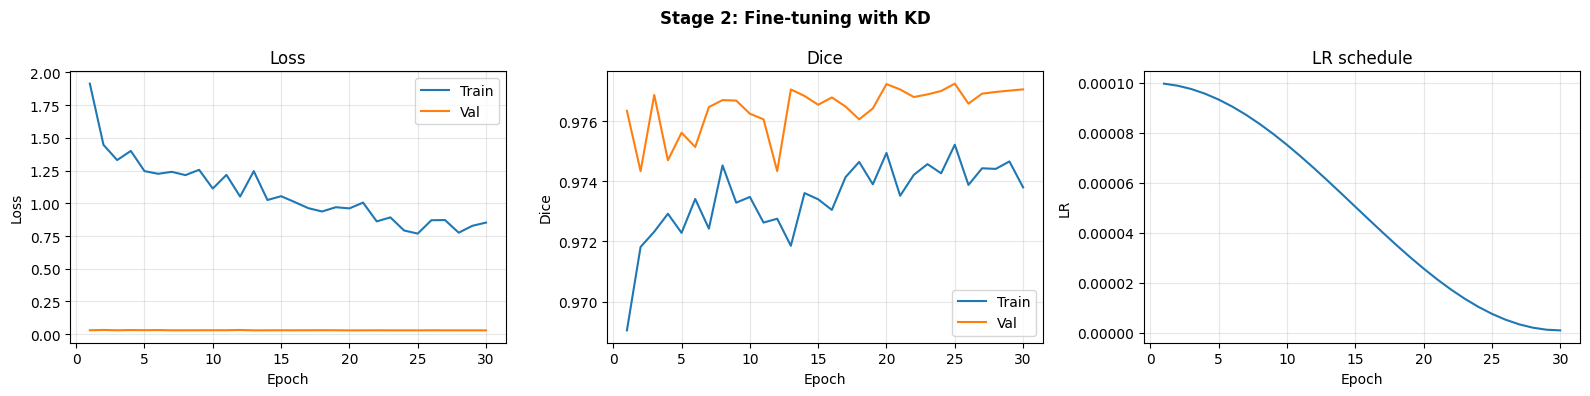

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = range(1, len(ft_history['train_loss'])+1)
axes[0].plot(x, ft_history['train_loss'], label='Train'); axes[0].plot(x, ft_history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(x, ft_history['train_dice'], label='Train'); axes[1].plot(x, ft_history['val_dice'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice'); axes[1].set_title('Dice'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(x, ft_history['lr']); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR'); axes[2].set_title('LR schedule'); axes[2].grid(alpha=0.3)
plt.suptitle('Stage 2: Fine-tuning with KD', fontweight='bold'); plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'ft_curves_v8.png'), dpi=130, bbox_inches='tight'); plt.show()

## 9. Stage 3: Comprehensive Evaluation

In [ ]:
print('=== FINAL EVALUATION ===')
phase0_test = evaluate_static(phase0_model, test_pairs)
print(f'Phase 0:  Dice={phase0_test["mean_dice"]*100:.2f}% | MAE={phase0_test["mean_mae"]:.2f}mm')
print(f'Pre-FT:   Dice={pre_ft_test["mean_dice"]*100:.2f}% | MAE={pre_ft_test["mean_mae"]:.2f}mm')
phase4a_test = evaluate_static(pruned_model, test_pairs)
print(f'Post-FT:  Dice={phase4a_test["mean_dice"]*100:.2f}% | MAE={phase4a_test["mean_mae"]:.2f}mm')

dd = phase0_test['mean_dice'] - phase4a_test['mean_dice']
dm = phase4a_test['mean_mae'] - phase0_test['mean_mae']
recovery = (phase4a_test['mean_dice'] - pre_ft_test['mean_dice']) / (phase0_test['mean_dice'] - pre_ft_test['mean_dice'] + 1e-8) * 100
print(f'\nDelta vs unpruned: Dice {-dd*100:+.2f}pp | MAE {dm:+.2f}mm')
print(f'FT recovery: {recovery:.1f}% of lost Dice recovered')
print(f'ISUOG: Phase 0 {"PASS" if phase0_test["mean_mae"]<=3 else "FAIL"} | Phase 4a {"PASS" if phase4a_test["mean_mae"]<=3 else "FAIL"}')

def measure_latency(model, n_reps=50, warmup=10):
    model.eval(); x = torch.randn(1,1,INPUT_H,INPUT_W).to(DEVICE)
    with torch.no_grad():
        for _ in range(warmup): model(x)
    times = []
    for _ in range(n_reps):
        torch.cuda.synchronize(); t0 = time.perf_counter()
        with torch.no_grad(): model(x)
        torch.cuda.synchronize(); times.append((time.perf_counter()-t0)*1000)
    return np.mean(times), np.std(times)

lat0_m,lat0_s = measure_latency(phase0_model); lat4_m,lat4_s = measure_latency(pruned_model)
speedup = lat0_m/(lat4_m+1e-8)
p0_params = sum(p.numel() for p in phase0_model.parameters())
p4_params = sum(p.numel() for p in pruned_model.parameters())
print(f'\nLatency: {lat0_m:.1f}ms -> {lat4_m:.1f}ms ({speedup:.2f}x)')
print(f'Params: {p0_params/1e6:.2f}M -> {p4_params/1e6:.2f}M ({(1-p4_params/p0_params)*100:.1f}% smaller)')

=== FINAL EVALUATION ===
Phase 0:  Dice=97.75% | MAE=1.65mm
Pre-FT:   Dice=96.39% | MAE=2.55mm
Post-FT:  Dice=97.64% | MAE=1.76mm

Delta vs unpruned: Dice -0.12pp | MAE +0.11mm
FT recovery: 91.5% of lost Dice recovered
ISUOG: Phase 0 PASS | Phase 4a PASS

Latency: 11.6ms -> 9.9ms (1.17x)
Params: 8.11M -> 4.57M (43.7% smaller)


In [ ]:
from thop import profile as thop_profile
dummy = torch.randn(1,1,INPUT_H,INPUT_W).to(DEVICE)
macs0,_ = thop_profile(phase0_model, inputs=(dummy,), verbose=False)
macs4,_ = thop_profile(pruned_model, inputs=(dummy,), verbose=False)
flops0=macs0*2; flops4=macs4*2; mac_ratio=macs4/(macs0+1e-8)
print(f'FLOPs: {flops0/1e9:.2f} -> {flops4/1e9:.2f} GFLOPs ({(1-flops4/flops0)*100:.1f}% reduction)')
print(f'MACs: {macs0/1e9:.2f} -> {macs4/1e9:.2f} GMACs')

FLOPs: 43.15 -> 33.11 GFLOPs (23.3% reduction)
MACs: 21.58 -> 16.56 GMACs


Wilcoxon Dice: stat=2603.0, p=0.0049 (Sig at 0.05)
Tail <95%: Phase 0=4/121 | Phase 4a=6/121


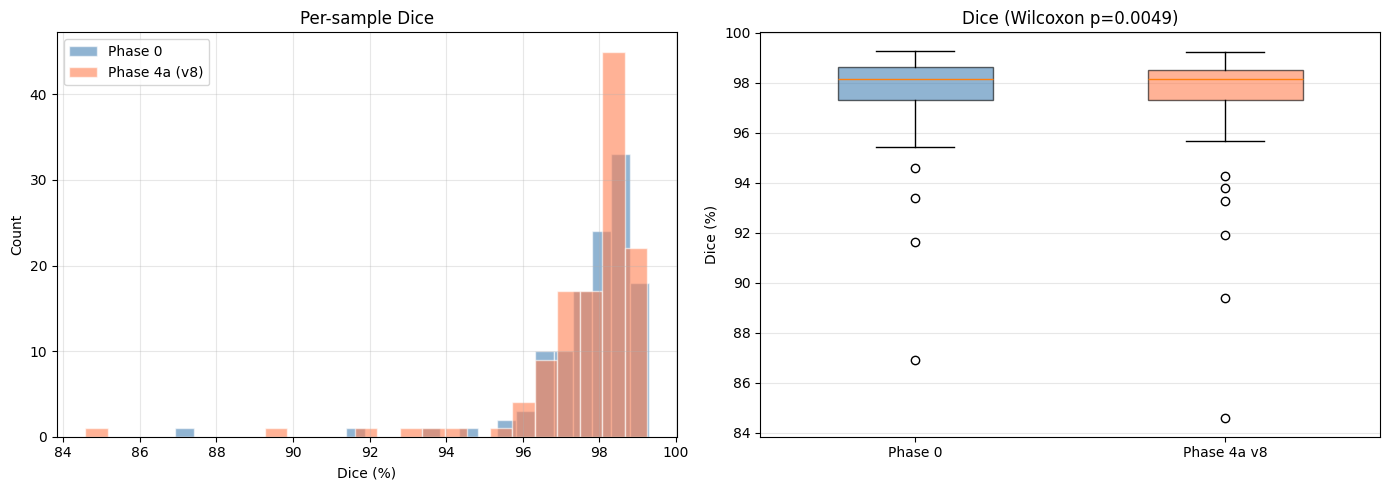

In [ ]:
# Per-sample Dice + Wilcoxon
dice_p0, mae_p0 = evaluate_per_sample(phase0_model, test_pairs)
dice_p4, mae_p4 = evaluate_per_sample(pruned_model, test_pairs)
dice_p0=np.array(dice_p0); dice_p4=np.array(dice_p4)
stat,pval = wilcoxon(dice_p0, dice_p4)
print(f'Wilcoxon Dice: stat={stat:.1f}, p={pval:.4f} ({"Sig" if pval<0.05 else "NS"} at 0.05)')
tail0=(dice_p0*100<95).sum(); tail4=(dice_p4*100<95).sum()
print(f'Tail <95%: Phase 0={tail0}/{len(dice_p0)} | Phase 4a={tail4}/{len(dice_p4)}')

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(dice_p0*100,bins=25,alpha=0.6,label='Phase 0',color='steelblue',edgecolor='white')
axes[0].hist(dice_p4*100,bins=25,alpha=0.6,label='Phase 4a (v8)',color='coral',edgecolor='white')
axes[0].set_xlabel('Dice (%)'); axes[0].set_ylabel('Count'); axes[0].set_title('Per-sample Dice'); axes[0].legend(); axes[0].grid(alpha=0.3)
bp = axes[1].boxplot([dice_p0*100, dice_p4*100], tick_labels=['Phase 0','Phase 4a v8'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('coral'); bp['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel('Dice (%)'); axes[1].set_title(f'Dice (Wilcoxon p={pval:.4f})'); axes[1].grid(alpha=0.3,axis='y')
plt.tight_layout(); plt.savefig(str(RESULTS_DIR/'dice_dist_v8.png'),dpi=130,bbox_inches='tight'); plt.show()

In [ ]:
# GPU memory + throughput + ONNX + cost
torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
x=torch.randn(1,1,INPUT_H,INPUT_W).to(DEVICE)
with torch.no_grad(): _=phase0_model(x)
mem0=torch.cuda.max_memory_allocated()/1e6
torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
with torch.no_grad(): _=pruned_model(x)
mem4=torch.cuda.max_memory_allocated()/1e6
print(f'GPU Mem: {mem0:.1f} -> {mem4:.1f} MB ({(1-mem4/mem0)*100:.1f}% reduction)')
del x

fps_results = {}
for bs in [1,4,8]:
    x=torch.randn(bs,1,INPUT_H,INPUT_W).to(DEVICE)
    with torch.no_grad():
        for _ in range(5): phase0_model(x)
    torch.cuda.synchronize(); t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(20): phase0_model(x)
    torch.cuda.synchronize(); f0=(20*bs)/(time.perf_counter()-t0)
    with torch.no_grad():
        for _ in range(5): pruned_model(x)
    torch.cuda.synchronize(); t0=time.perf_counter()
    with torch.no_grad():
        for _ in range(20): pruned_model(x)
    torch.cuda.synchronize(); f4=(20*bs)/(time.perf_counter()-t0)
    fps_results[bs]={'phase0':f0,'phase4a':f4}
    print(f'FPS batch={bs}: {f0:.1f} -> {f4:.1f} ({f4/f0:.2f}x)')
    del x
torch.cuda.empty_cache()

import onnx
onnx_p0=str(CKPT_DIR/'phase0.onnx'); onnx_p4=str(CKPT_DIR/'pruned_ft_v8.onnx')
dummy=torch.randn(1,1,INPUT_H,INPUT_W).to(DEVICE)
phase0_model.eval(); torch.onnx.export(phase0_model,dummy,onnx_p0,input_names=['input'],output_names=['output'],dynamic_axes={'input':{0:'b'},'output':{0:'b'}},opset_version=17)
pruned_model.eval(); torch.onnx.export(pruned_model,dummy,onnx_p4,input_names=['input'],output_names=['output'],dynamic_axes={'input':{0:'b'},'output':{0:'b'}},opset_version=17)
s0=os.path.getsize(onnx_p0)/1e6; s4=os.path.getsize(onnx_p4)/1e6
print(f'ONNX: {s0:.1f} -> {s4:.1f} MB ({(1-s4/s0)*100:.1f}% smaller)')

try:
    import onnxruntime as ort
    sess0=ort.InferenceSession(onnx_p0,providers=['CUDAExecutionProvider','CPUExecutionProvider'])
    sess4=ort.InferenceSession(onnx_p4,providers=['CUDAExecutionProvider','CPUExecutionProvider'])
    xn=np.random.randn(1,1,INPUT_H,INPUT_W).astype(np.float32)
    for _ in range(10): sess0.run(None,{'input':xn}); sess4.run(None,{'input':xn})
    t0=time.perf_counter()
    for _ in range(50): sess0.run(None,{'input':xn})
    lo0=(time.perf_counter()-t0)/50*1000
    t0=time.perf_counter()
    for _ in range(50): sess4.run(None,{'input':xn})
    lo4=(time.perf_counter()-t0)/50*1000
    print(f'ONNX RT: {lo0:.2f} -> {lo4:.2f} ms ({lo0/lo4:.2f}x)')
except Exception as e: print(f'ONNX RT failed: {e}'); lo0=lo4=None

GPU_COST=0.526
c0=(1000/fps_results[8]['phase0'])/3600*GPU_COST; c4=(1000/fps_results[8]['phase4a'])/3600*GPU_COST
print(f'Cost/1K scans (batch=8): ${c0:.4f} -> ${c4:.4f} | Annual saving @100K: ${(c0-c4)*100:.2f}')

GPU Mem: 228.2 -> 222.8 MB (2.4% reduction)
FPS batch=1: 87.2 -> 103.1 (1.18x)
FPS batch=4: 91.7 -> 104.3 (1.14x)
FPS batch=8: 93.1 -> 104.4 (1.12x)


/tmp/ipykernel_2552/15767658.py:35: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  phase0_model.eval(); torch.onnx.export(phase0_model,dummy,onnx_p0,input_names=['input'],output_names=['output'],dynamic_axes={'input':{0:'b'},'output':{0:'b'}},opset_version=17)
W0415 23:42:16.078000 2552 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResidualUNetDS([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResidualUNetDS([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅
Applied 36 of general pattern rewrite rules.


/tmp/ipykernel_2552/15767658.py:36: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  pruned_model.eval(); torch.onnx.export(pruned_model,dummy,onnx_p4,input_names=['input'],output_names=['output'],dynamic_axes={'input':{0:'b'},'output':{0:'b'}},opset_version=17)
W0415 23:42:22.376000 2552 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResidualUNetDS([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResidualUNetDS([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 36 of general pattern rewrite rules.
ONNX: 0.0 -> 0.0 MB (-1.0% smaller)
ONNX RT: 11.92 -> 14.58 ms (0.82x)
Cost/1K scans (batch=8): $0.0016 -> $0.0014 | Annual saving @100K: $0.02


## 10. Ablation Table, Plots, and Model Card

=== 3-WAY ABLATION ===
           Config  Dice  MAE ISUOG Params GMACs Latency            Channels
       A: Phase 0 97.75 1.65  PASS  8.11M 21.58  11.6ms 128/256/512/256/128
B: Pruned (no FT) 96.39 2.55  PASS  4.57M 16.56   9.9ms   71/129/257/129/65
  C: Pruned+FT+KD 97.64 1.76  PASS  4.57M 16.56   9.9ms   71/129/257/129/65


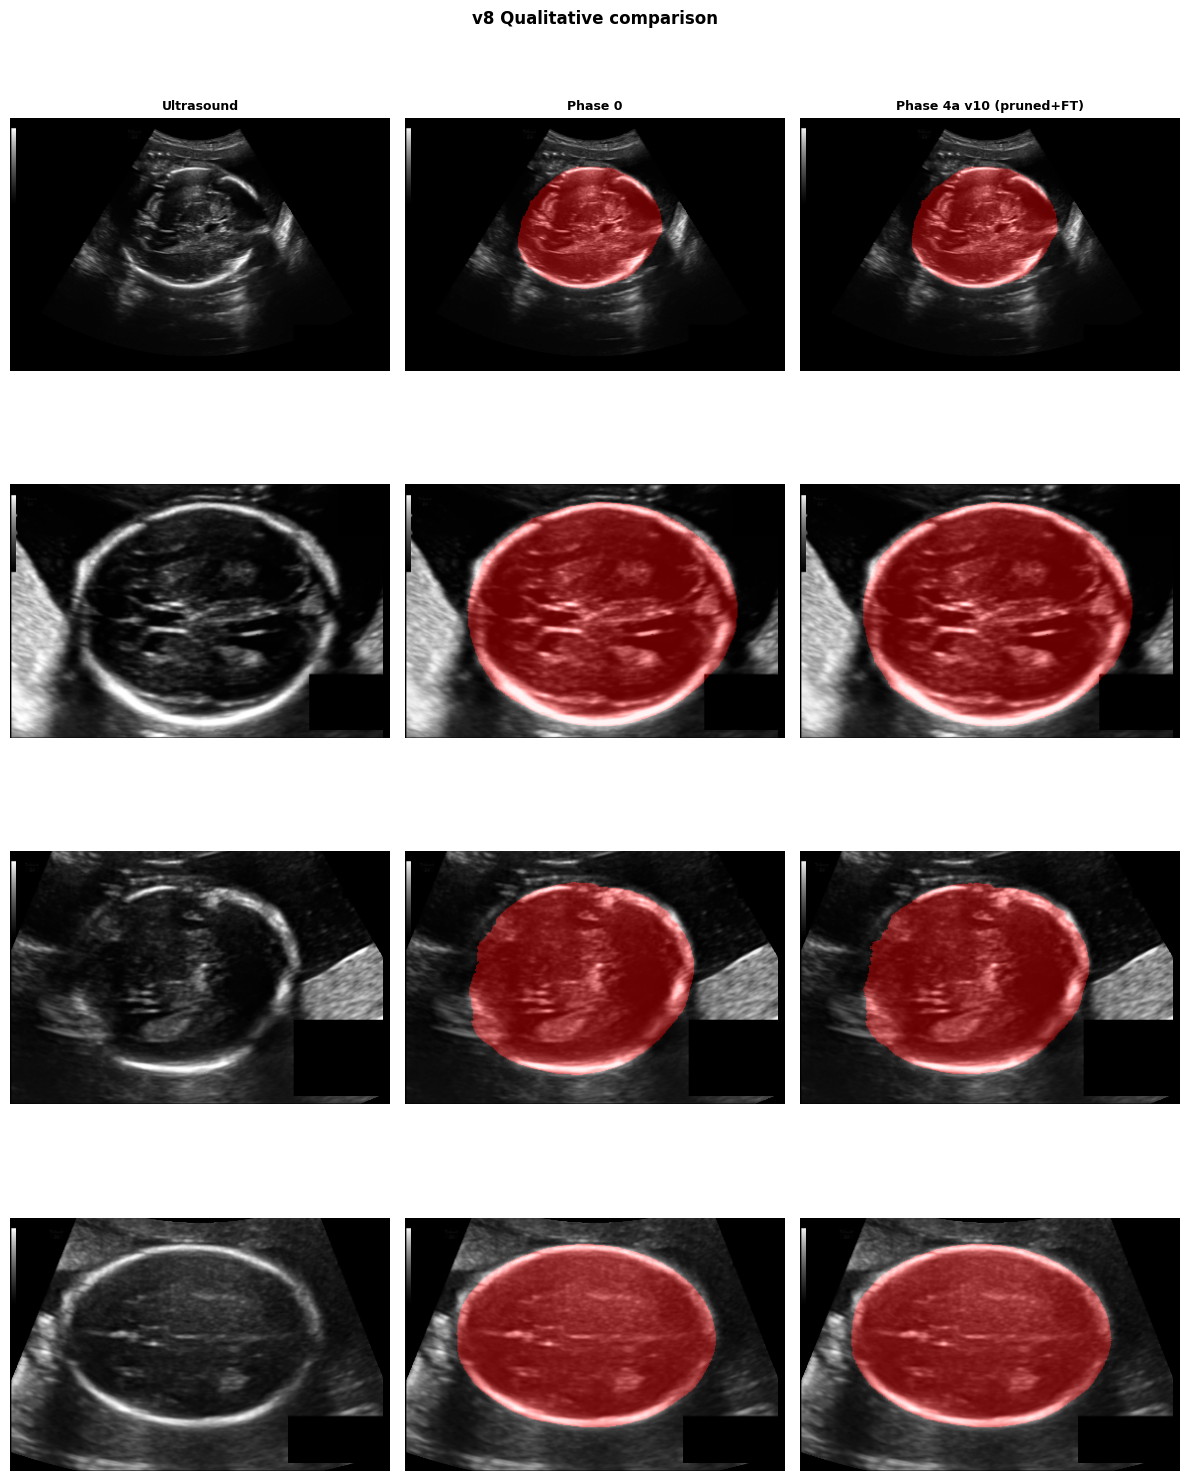

Model card saved.
=== PHASE 4a v10 COMPLETE ===


In [ ]:
fc = get_channel_counts(pruned_model)
ablation = [
    {'Config':'A: Phase 0','Dice':f'{phase0_test["mean_dice"]*100:.2f}','MAE':f'{phase0_test["mean_mae"]:.2f}',
     'ISUOG':'PASS' if phase0_test['mean_mae']<=3 else 'FAIL','Params':f'{p0_params/1e6:.2f}M',
     'GMACs':f'{macs0/1e9:.2f}','Latency':f'{lat0_m:.1f}ms',
     'Channels':'/'.join(str(orig_counts[b]) for b in PRUNABLE_BLOCKS)},
    {'Config':'B: Pruned (no FT)','Dice':f'{pre_ft_test["mean_dice"]*100:.2f}','MAE':f'{pre_ft_test["mean_mae"]:.2f}',
     'ISUOG':'PASS' if pre_ft_test['mean_mae']<=3 else 'FAIL','Params':f'{p4_params/1e6:.2f}M',
     'GMACs':f'{macs4/1e9:.2f}','Latency':f'{lat4_m:.1f}ms',
     'Channels':'/'.join(str(fc[b]) for b in PRUNABLE_BLOCKS)},
    {'Config':'C: Pruned+FT+KD','Dice':f'{phase4a_test["mean_dice"]*100:.2f}','MAE':f'{phase4a_test["mean_mae"]:.2f}',
     'ISUOG':'PASS' if phase4a_test['mean_mae']<=3 else 'FAIL','Params':f'{p4_params/1e6:.2f}M',
     'GMACs':f'{macs4/1e9:.2f}','Latency':f'{lat4_m:.1f}ms',
     'Channels':'/'.join(str(fc[b]) for b in PRUNABLE_BLOCKS)},
]
df=pd.DataFrame(ablation); df.to_csv(str(RESULTS_DIR/'ablation_v10.csv'),index=False)
print('=== 3-WAY ABLATION ==='); print(df.to_string(index=False))

# Pruning trajectory
acc_log = [l for l in pruning_log if l['action'] in ['HYBRID','STANDARD_DROP']]
if acc_log:
    fig,(a1,a2)=plt.subplots(2,1,figsize=(12,7),sharex=True)
    steps=[l['step'] for l in acc_log]
    a1.plot(steps,[l['dice']*100 for l in acc_log],'b-o',markersize=2)
    a1.axhline(BASELINE_DICE*100,color='g',ls='--',label='Baseline')
    a1.axhline((BASELINE_DICE-DICE_DROP_MAX)*100,color='r',ls=':',label='Guard rail')
    a1.axhline(phase4a_test['mean_dice']*100,color='purple',ls='-.',label='After FT')
    a1.set_ylabel('Dice (%)'); a1.legend(); a1.grid(alpha=0.3)
    a2.plot(steps,[l['mae'] for l in acc_log],'r-o',markersize=2)
    a2.axhline(BASELINE_MAE,color='g',ls='--'); a2.axhline(3.0,color='orange',ls='--',label='ISUOG 3mm')
    a2.axhline(phase4a_test['mean_mae'],color='purple',ls='-.',label='After FT')
    a2.set_ylabel('MAE (mm)'); a2.set_xlabel('Step'); a2.legend(); a2.grid(alpha=0.3)
    plt.suptitle('v8: Prune 5 blocks then Recover',fontweight='bold'); plt.tight_layout()
    plt.savefig(str(RESULTS_DIR/'trajectory_v10.png'),dpi=130,bbox_inches='tight'); plt.show()

# Qualitative
N=4; fig,axes=plt.subplots(N,3,figsize=(12,N*4))
for col,t in enumerate(['Ultrasound','Phase 0','Phase 4a v10 (pruned+FT)']): axes[0,col].set_title(t,fontweight='bold',fontsize=9)
for row,(ip,mp) in enumerate(test_pairs[:N]):
    img,mask=load_static_pair(ip,mp); it=img_to_tensor(img)
    with torch.no_grad():
        p0=(torch.sigmoid(phase0_model(it.to(DEVICE))).cpu().squeeze().numpy()>0.5).astype(np.uint8)
        p4=(torch.sigmoid(pruned_model(it.to(DEVICE))).cpu().squeeze().numpy()>0.5).astype(np.uint8)
    o0=np.stack([img]*3,axis=-1).astype(float)/255; o0[:,:,0]=np.clip(o0[:,:,0]+p0*0.4,0,1)
    o4=np.stack([img]*3,axis=-1).astype(float)/255; o4[:,:,0]=np.clip(o4[:,:,0]+p4*0.4,0,1)
    axes[row,0].imshow(img,cmap='gray'); axes[row,0].axis('off')
    axes[row,1].imshow(o0); axes[row,1].axis('off')
    axes[row,2].imshow(o4); axes[row,2].axis('off')
plt.suptitle('v8 Qualitative comparison',fontweight='bold'); plt.tight_layout()
plt.savefig(str(RESULTS_DIR/'qualitative_v10.png'),dpi=130,bbox_inches='tight'); plt.show()

# Model card
mc=['# Model Card -- Phase 4a v10: Full-Scope Pruning + FT Recovery','',
    f'**Pruned blocks:** ' + ', '.join(f'{b} ({orig_counts[b]}->{fc[b]})' for b in PRUNABLE_BLOCKS),
    f'**Fine-tuning:** {FT_EPOCHS} epochs KD (alpha={KD_ALPHA}, T={KD_TEMP})', '',
    '## Results',
    f'| Metric | Phase 0 | Pre-FT | Post-FT |',
    f'|--------|---------|--------|---------|',
    f'| Dice | {phase0_test["mean_dice"]*100:.2f}% | {pre_ft_test["mean_dice"]*100:.2f}% | {phase4a_test["mean_dice"]*100:.2f}% |',
    f'| MAE | {phase0_test["mean_mae"]:.2f}mm | {pre_ft_test["mean_mae"]:.2f}mm | {phase4a_test["mean_mae"]:.2f}mm |',
    f'| Params | {p0_params/1e6:.2f}M | {p4_params/1e6:.2f}M | {p4_params/1e6:.2f}M |',
    f'| GFLOPs | {flops0/1e9:.2f} | {flops4/1e9:.2f} | {flops4/1e9:.2f} |',
    f'| Latency | {lat0_m:.1f}ms | {lat4_m:.1f}ms | {lat4_m:.1f}ms |', '',
    f'Wilcoxon p={pval:.4f} | FT recovery: {recovery:.1f}%', '',
    '## References',
    '- Sadarla 2025: Hybrid Crossover (UNT directed study)',
    '- MIDL 2025: nnU-Net bottleneck most prunable',
    '- Mangalam & Salzmann 2018: U-Net KD 1000x compression',
    '- Renda et al. 2020: LR rewinding (ICLR)']
with open(str(RESULTS_DIR/'MODEL_CARD_V8.md'),'w') as f: f.write('\n'.join(mc))
print('Model card saved.\n=== PHASE 4a v10 COMPLETE ===')